In [1]:
import pandas as pd
import os,re,glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Ellipse
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]


dates={"CW1A": "2024-07-25", "CW2A": "2024-08-01", "CW3A": "2024-08-07",
 "EXPUPS1A": "2024-07-25", "EXPUPS2A": "2024-08-01", "EXPUPS3A": "2024-08-07",
 "EXPMDS1B": "2024-07-25", "EXPMDS2B": "2024-08-01", 
 "EXPDWS1C": "2024-07-25", "EXPDWS2C": "2024-08-01", "EXPDWS3C": "2024-08-07",
 "PETUPS1A": "2024-07-25", "PETUPS2A": "2024-08-01", "PETUPS3A": "2024-08-07",
  "PETDWS2B": "2024-08-01",  "PETDWS2C": "2024-08-01",  "MBUPS1A": "2024-07-25", "MBUPS2A": "2024-08-01", "MBUPS3A": "2024-08-07",
 "MBMDS1B": "2024-07-25", "MBMDS2B": "2024-08-01", "MBMDS3B": "2024-08-07",
 "MBDWS1C": "2024-07-25", "MBDDWS2C": "2024-08-01", "MBDWS3C": "2024-08-07",
 "AJBUPS1A": "2024-07-25", "AJBUPS2A": "2024-08-01", "AJBUPS3A": "2024-08-07",
  "AJBMDS2B": "2024-08-01", "AJBMDS3B": "2024-08-07",
 "AJBDWS1C": "2024-07-25", "AJBDWS2C": "2024-08-01", "AJBDWS3C": "2024-08-07",
 "AJA1A": "2024-07-25", "AJA2A": "2024-08-01", "AJA3A": "2024-08-07"}

pop_catchment={"EXP":1554771, "CW":1607903, "AJA":926846, "MB": 1554572,"PET":533714, "AJB":527665}

area_sqkm={"EXP":56.059150,"CW":58.334600,  "AJA": 19.292530, "MB": 56.051600, "PET":34.747900,  "AJB":34.477040}


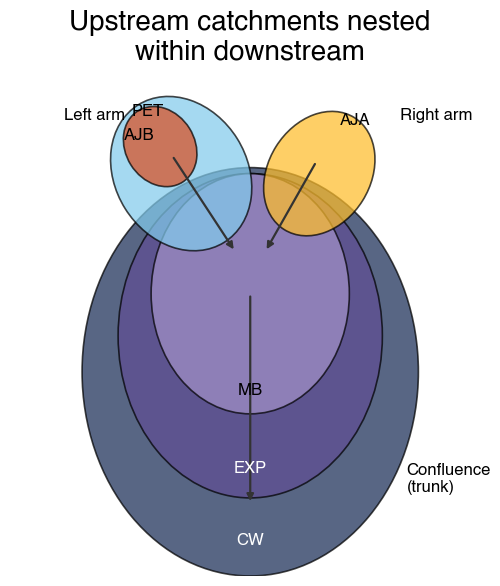

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))

cats = [ ( 0.0, -1.6, 5.6, 6.8,   0, "#182b55", "CW",  ( 0.0, -4.4)),  ( 0.0, -1.0, 4.4, 5.4,   0, "#5f4e94", "EXP", ( 0.0, -3.2)),  ( 0.0, -0.3, 3.3, 4.0,   0, "#a291c7", "MB",  ( 0.0, -1.9)),  (-1.15, 1.7, 2.2, 2.7,  32, "#82cbec", "PET", (-1.70, 2.75)),  (-1.50, 2.15,1.15,1.4,  32, "#d94f21", "AJB", (-1.85, 2.35)), ( 1.15, 1.7, 1.7, 2.2, -32, "#febd2b", "AJA", ( 1.75, 2.60)),]

df = {"CW", "EXP"}      
for cx, cy, w, h, ang, col, lab, _ in cats:
    ax.add_patch(Ellipse((cx, cy), w, h, angle=ang, facecolor=col,
                         edgecolor="black", lw=1.2, alpha=0.72, zorder=1))
for cx, cy, w, h, ang, col, lab, (lx, ly) in cats:
    ax.text(lx, ly, lab, ha="center", va="center", fontsize=12, fontweight="bold",
            color="white" if lab in df else "black", zorder=5)

for xy, xytext in [((-0.25,0.4),(-1.3,2.0)), ((0.25,0.4),(1.1,1.9)), ((0,-3.8),(0,-0.3))]:
    ax.annotate("", xy=xy, xytext=xytext, arrowprops=dict(arrowstyle="-|>", lw=1.6, color="#333"))

ax.text(-3.1, 2.6, "Left arm", fontsize=12, color="black")
ax.text( 2.5, 2.6, "Right arm", fontsize=12, color="black")
ax.text( 2.6, -3.6, "Confluence\n(trunk)", fontsize=12, color="black")
ax.text(0, 3.6, "Upstream catchments nested\nwithin downstream", ha="center", fontsize=20)

ax.set_xlim(-4, 4); ax.set_ylim(-5, 4)
ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout()


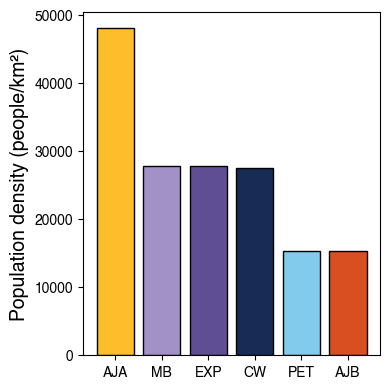

In [8]:
cc = { "CW": "#182b55", "EXP": "#5f4e94",  "MB": "#a291c7","PET": "#82cbec",  "AJB": "#d94f21", "AJA": "#febd2b",}

def to_canal(label):
    label = str(label)
    if label.startswith("MB"):
        return "MB"
    return label  

df = pd.DataFrame({"sample": list(pop_catchment.keys()), "population": [pop_catchment[x] for x in pop_catchment],"area_sqkm": [area_sqkm[x] for x in pop_catchment]})
df["population_density"] = df["population"] / df["area_sqkm"]
df = df.sort_values("population_density", ascending=False)
df["bar_col"] = df["sample"].map(to_canal).map(cc).fillna("grey")

fig, ax = plt.subplots(figsize=(4, 4))

ax.bar(df["sample"],df["population_density"],color=df["bar_col"],edgecolor="black",linewidth=1)
ax.set_ylabel("Population density (people/km²)", size=14)
plt.tight_layout()

plt.show()

In [7]:
esv=pd.read_csv("ESV_across_canal_bc.csv")
esv["method"]="ESV"
ku=pd.read_csv("KU_across_canal_bc.csv")
ku["method"]="KU"
MT=pd.concat([esv, ku])

In [9]:
MT

,Unnamed: 0,date,canal_1,canal_2,pair,bray_curtis,similarity,method
0,0,2024-07-25,AJA,AJB,AJA-AJB,0.699142,0.300858,ESV
1,1,2024-07-25,AJA,PET,AJA-PET,0.590462,0.409538,ESV
2,2,2024-07-25,AJA,MB,AJA-MB,0.739481,0.260519,ESV
3,3,2024-07-25,AJA,EXP,AJA-EXP,0.753592,0.246408,ESV
4,4,2024-07-25,AJA,CW,AJA-CW,0.796981,0.203019,ESV
...,...,...,...,...,...,...,...,...
40,40,2024-08-07,PET,EXP,PET-EXP,0.262655,0.737345,KU
41,41,2024-08-07,PET,CW,PET-CW,0.469926,0.530074,KU
42,42,2024-08-07,MB,EXP,MB-EXP,0.405817,0.594183,KU
43,43,2024-08-07,MB,CW,MB-CW,0.458989,0.541011,KU


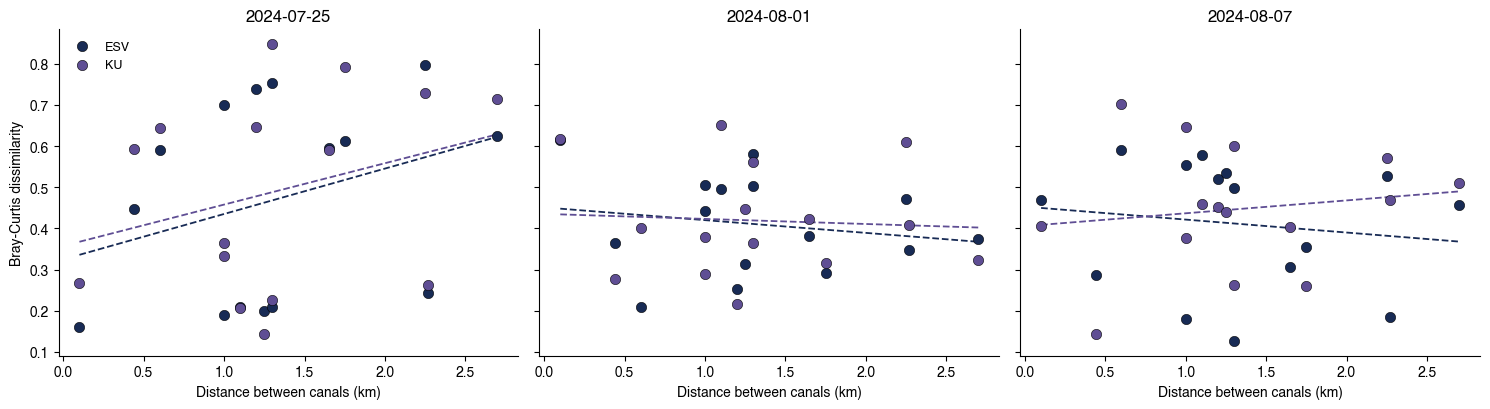

In [10]:
df = MT.copy()
df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")
df["bray_curtis"] = pd.to_numeric(df["bray_curtis"], errors="coerce")

dists = {("AJB","PET"):0.44,("AJB","MB"):1.65,("AJB","EXP"):1.75,("AJB","CW"):2.70,("AJB","AJA"):1.0,("PET","MB"):1.25,("PET","EXP"):1.30,("PET","CW"):2.27,("PET","AJA"):0.6,("AJA","MB"):1.20,("AJA","EXP"):1.30,("AJA","CW"):2.25, ("MB","EXP"):0.10,("MB","CW"):1.10,("EXP","CW"):1.00}

def get_dist(r):                     
    return dists.get((r.canal_1, r.canal_2), dists.get((r.canal_2, r.canal_1)))
df["distance_km"] = df.apply(get_dist, axis=1)
df = df.dropna(subset=["distance_km","bray_curtis","method","date"])

d   = sorted(df["date"].unique())
m = sorted(df["method"].unique())
mcols = dict(zip(m, ["#182b55", "#5f4e94", "#82cbec", "#d94f21"]))

fig, axes = plt.subplots(1, len(d), figsize=(5*len(d), 4.2),sharex=True, sharey=True, squeeze=False)
for ax, date in zip(axes[0], d):
    sub = df[df.date == date]
    for method in m:
        d = sub[sub.method == method]
        ax.scatter(d.distance_km, d.bray_curtis, color=mcols[method], s=55,edgecolor="black", linewidth=0.4, label=method, zorder=3)
        if len(d) >= 2:               
            m, b = np.polyfit(d.distance_km, d.bray_curtis, 1)
            xs = np.linspace(d.distance_km.min(), d.distance_km.max(), 50)
            ax.plot(xs, m*xs + b, "--", color=mcols[method], lw=1.3, zorder=2)
    ax.set_title(date, fontsize=12)
    ax.set_xlabel("Distance between canals (km)", fontsize=10)
    # ax.grid(ls=":", lw=0.5, alpha=0.6)
    ax.spines[["top","right"]].set_visible(False)

axes[0][0].set_ylabel("Bray-Curtis dissimilarity", fontsize=10)
axes[0][0].legend(title="", fontsize=9, title_fontsize=10, frameon=False, loc="upper left")
plt.tight_layout()


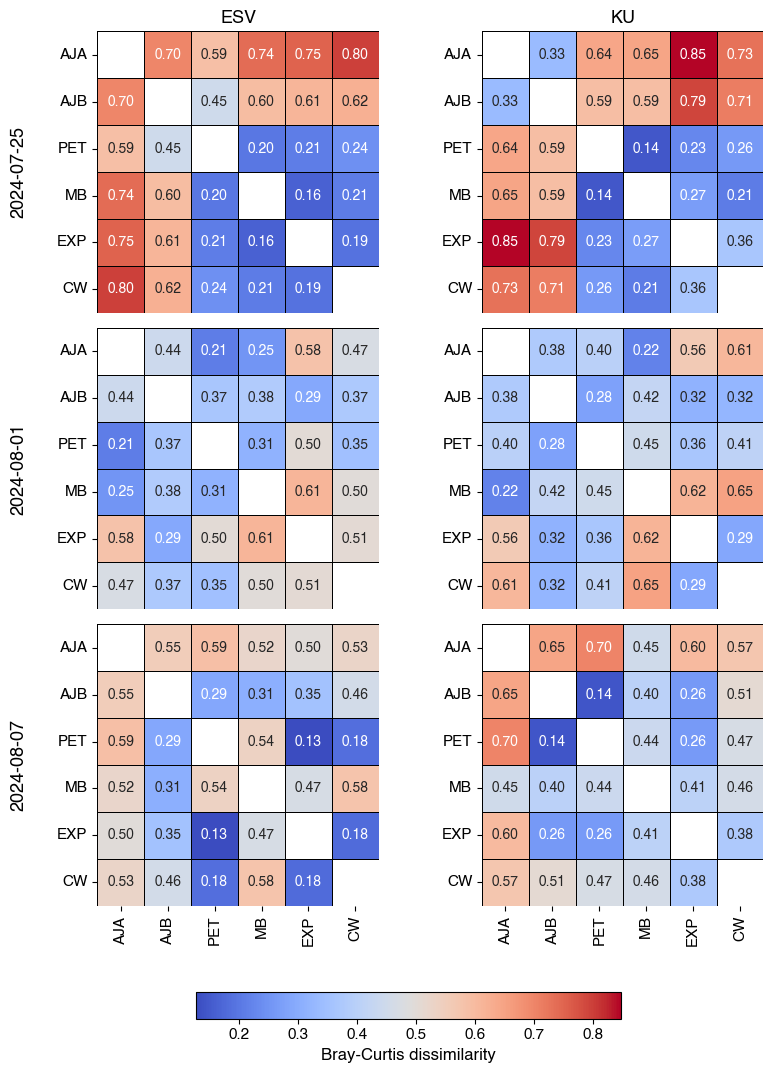

In [11]:
plot_df = MT.copy()

def symmetric_pivot(sub):
    m = pd.DataFrame(np.nan, index=co, columns=co)
    for _, r in sub.iterrows():
        m.loc[r.canal_1, r.canal_2] = r.bray_curtis
        m.loc[r.canal_2, r.canal_1] = r.bray_curtis
    return m
    
plot_df["date"] = pd.to_datetime(plot_df["date"]).dt.strftime("%Y-%m-%d")
plot_df["bray_curtis"] = pd.to_numeric(plot_df["bray_curtis"], errors="coerce")
plot_df = plot_df.dropna(subset=["method","date","canal_1","canal_2","bray_curtis"])                      
m = [m for m in ["ESV", "KU"]  if m in plot_df["method"].unique()]
d   = sorted(plot_df["date"].unique())
co = [c for c in ["AJA","AJB","PET","MB","EXP","CW"] if c in set(plot_df.canal_1) | set(plot_df.canal_2)]

vmin, vmax = plot_df["bray_curtis"].min(), plot_df["bray_curtis"].max()  


fig, axes = plt.subplots(nrows=len(d), ncols=len(m), figsize=(4*len(m)+0.5, 3.5*len(d)), squeeze=False)

for i, date in enumerate(d):
    for j, method in enumerate(m):
        ax = axes[i, j]
        sub = plot_df[(plot_df.date == date) & (plot_df.method == method)]
        heat = symmetric_pivot(sub)
        sns.heatmap(heat, ax=ax, cmap="coolwarm", vmin=vmin, vmax=vmax, square=True, linewidths=0.5, linecolor="black", annot=True, fmt=".2f", cbar=False, mask=heat.isna())     
        ax.set_title(method, fontsize=13) if i == 0 else ax.set_title("")
        ax.set_xlabel(""); ax.set_ylabel("")
        if i < len(d) - 1:
            ax.set_xticks([])
        else:
            ax.tick_params(axis="x", rotation=90, labelsize=11)
        ax.tick_params(axis="y", rotation=0, labelsize=11)
        if j == 0:
            ax.text(-0.28, 0.5, date, transform=ax.transAxes, rotation=90, va="center", ha="center", fontsize=13)

plt.tight_layout(rect=[0, 0.08, 1, 1])
cbar_ax = fig.add_axes([0.25, 0.025, 0.5, 0.025])
sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin, vmax), cmap="coolwarm")
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Bray-Curtis dissimilarity", fontsize=12); cbar.ax.tick_params(labelsize=11)


In [12]:
# MT.to_csv("BC_test.csv", index=None)

In [13]:
df = pd.DataFrame({"canal": ["AJA", "AJB", "CW", "EXP", "MB", "PET"], "filtered_strain_count": [32, 22, 17, 28, 47, 24]})
df

,canal,filtered_strain_count
0,AJA,32
1,AJB,22
2,CW,17
3,EXP,28
4,MB,47
5,PET,24


In [14]:
tdf=pd.read_csv("read_counts_seqkit.csv")
tdf["sample"]=tdf["file"].str.replace(".AACMFLCHV.1.cleaned_bbdukclean_R1.fastq.gz", "")
rd=dict(zip(tdf['sample'], tdf['num_seqs']))
esv_tdf=pd.read_csv("esv_read_counts_prefilter.csv")
esv_tdf["total"]=esv_tdf["sample_ID"].map(rd)
esv_tdf["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in esv_tdf["sample_ID"]]
rdf=esv_tdf.groupby("canal", as_index=False)["read_count"].sum()
rr=dict(zip(rdf["canal"], rdf["read_count"]))

In [15]:
df["viral_reads"]=df["canal"].map(rr)

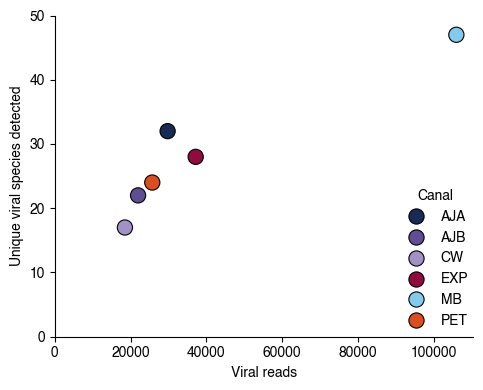

In [16]:
cols = ["#182b55", "#5f4e94", "#a291c7", "#900c3f","#82cbec", "#d94f21", "#febd2b", "#9aab4b", "#8C92AC", "#9b2226", "#6a4c93", "#1982c4", "#8ac926", "#ff595e", "#FFFDD0", "#ffca3a", "#8338ec", "#3a86ff",]
co = sorted(df["canal"].dropna().unique())
canal_cols = {canal: cols[i % len(cols)] for i, canal in enumerate(co)}

fig, ax = plt.subplots(figsize=(5, 4))
sns.scatterplot(data=df, x="viral_reads", y="filtered_strain_count", hue="canal", hue_order=co, palette=canal_cols, s=120, edgecolor="black", linewidth=0.8,ax=ax)
ax.set_xlabel("Viral reads")
ax.set_ylabel("Unique viral species detected")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(title="Canal", frameon=False, bbox_to_anchor=(0.8, 0.5), loc="upper left")

ax.set_xlim(left=0)
ax.set_ylim(0, 50)
plt.tight_layout()

plt.show()

In [ ]:
rho, p_spearman = spearmanr(df["viral_reads"], df["filtered_strain_count"])
r, p_pearson = pearsonr(df["viral_reads"], df["filtered_strain_count"])

In [19]:
df = pd.DataFrame({"canal": ["AJA", "AJA", "AJA","AJB", "AJB", "AJB","CW", "CW", "CW","EXP", "EXP", "EXP","MB", "MB", "MB","PET", "PET", "PET"],"date": ["2024-07-25", "2024-08-01", "2024-08-07","2024-07-25", "2024-08-01", "2024-08-07","2024-07-25", "2024-08-01", "2024-08-07","2024-07-25", "2024-08-01", "2024-08-07","2024-07-25", "2024-08-01", "2024-08-07","2024-07-25", "2024-08-01", "2024-08-07"],"filtered_strain_count": [14, 18, 16,5, 17, 15,4, 5, 15,20, 6, 10,21, 35, 31,13, 11, 11]})
df["date"] = pd.to_datetime(df["date"])
df["date"]=df["date"].astype(str)

In [20]:
esv_tdf["date"]=esv_tdf["sample_ID"].str.replace("_", "").map(dates)
esv_tdf["date"]=esv_tdf["date"].astype(str)

In [21]:
esv_tdf_reads = esv_tdf.groupby(["canal", "date"], as_index=False)["read_count"].sum()

In [22]:
df=pd.merge(df, esv_tdf_reads, on=["canal", "date"])

In [23]:
df

,canal,date,filtered_strain_count,read_count
0,AJA,2024-07-25,14,4118
1,AJA,2024-08-01,18,15980
2,AJA,2024-08-07,16,9684
3,AJB,2024-07-25,5,2821
4,AJB,2024-08-01,17,8164
5,AJB,2024-08-07,15,11000
6,CW,2024-07-25,4,1117
7,CW,2024-08-01,5,1064
8,CW,2024-08-07,15,16333
9,EXP,2024-07-25,20,26186


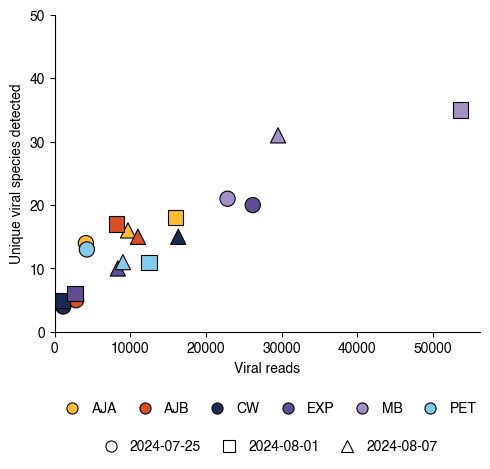

In [25]:
cols = ["#182b55", "#5f4e94", "#a291c7", "#900c3f","#82cbec", "#d94f21", "#febd2b", "#9aab4b","#8C92AC", "#9b2226", "#6a4c93", "#1982c4", "#8ac926", "#ff595e", "#FFFDD0", "#ffca3a","#8338ec", "#3a86ff",]
canal_colors = {"CW": "#182b55", "EXP": "#5f4e94", "MB": "#a291c7", "PET": "#82cbec", "AJB": "#d94f21", "AJA": "#febd2b",}

plot_df = df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["date_label"] = plot_df["date"].dt.strftime("%Y-%m-%d")
plot_df["read_count"] = pd.to_numeric(plot_df["read_count"], errors="coerce")
plot_df["filtered_strain_count"] = pd.to_numeric(plot_df["filtered_strain_count"], errors="coerce")

co = sorted(plot_df["canal"].dropna().unique())
do = sorted(plot_df["date_label"].dropna().unique())
canal_cols = {canal: canal_colors.get(canal, cols[i % len(cols)]) for i, canal in enumerate(co)}
ms = ["o", "s", "^", "D", "P", "X"]
dms = {date: ms[i % len(ms)] for i, date in enumerate(do)}

fig, ax = plt.subplots(figsize=(5, 5))

sns.scatterplot(data=plot_df, x="read_count", y="filtered_strain_count", hue="canal", hue_order=co, palette=canal_cols, style="date_label", style_order=do, markers=dms, s=120, edgecolor="black", linewidth=0.8, ax=ax, legend=False)
ax.set_xlabel("Viral reads")
ax.set_ylabel("Unique viral species detected")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(left=0)
ax.set_ylim(0, 50)

ch = [Line2D([0], [0], marker="o",linestyle="", label=canal, markerfacecolor=canal_cols[canal], markeredgecolor="black", markeredgewidth=0.8, markersize=8) for canal in co]

l1 = ax.legend( handles=ch, title=None, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=len(co), handletextpad=0.4, columnspacing=1.0)
ax.add_artist(l1)
dhs = [Line2D([0], [0],marker=dms[date], linestyle="", label=date, markerfacecolor="white", markeredgecolor="black", markeredgewidth=0.8, markersize=8) for date in do]
ax.legend(handles=dhs, title=None, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.30),ncol=len(do), handletextpad=0.4, columnspacing=1.0)
plt.tight_layout()

plt.show()

In [ ]:
corr_df = df.copy()
corr_df["read_count"] = pd.to_numeric(corr_df["read_count"], errors="coerce")
corr_df["filtered_strain_count"] = pd.to_numeric(corr_df["filtered_strain_count"], errors="coerce")
corr_df = corr_df.dropna(subset=["read_count", "filtered_strain_count"])
rho, p_spearman = spearmanr( corr_df["read_count"], corr_df["filtered_strain_count"])
r, p_pearson = pearsonr( corr_df["read_count"], corr_df["filtered_strain_count"])